In [126]:
import numpy as np 
import matplotlib.pyplot as plt 
#%matplotlib inline

In [235]:
data = np.load("field-aberrations.pkl",allow_pickle=True)

In [236]:
z = np.asarray([x[0] for x in data] )
data[0],data[-1]

((-10.0,
  [-1462.8941514878136,
   120.02445660902167,
   0.07472002343305709,
   -608.5216005728729,
   0.017158537319875062,
   -5122.909264261844,
   -0.04497458603727898,
   102.0625542274282,
   0.000783690205946363,
   2.850244688453658,
   27.53750733875248,
   -14.71873855301392,
   0.0008390326474114606,
   0.004703840763681932,
   -0.00020336853104539922]),
 (10.0,
  [-1460.5787206954576,
   -121.60570543291045,
   0.07397609392303549,
   -611.5719951468653,
   0.018547703314445368,
   -5121.908065886893,
   0.014513218037121361,
   -101.92448337844665,
   0.0004372522800493105,
   -2.839759748105149,
   27.515183615089292,
   -14.71801891048132,
   -0.0008120945756202864,
   0.0044731879510476235,
   0.00019312520664747582]))

Text(0.5, 0, 'Zernike mode #')

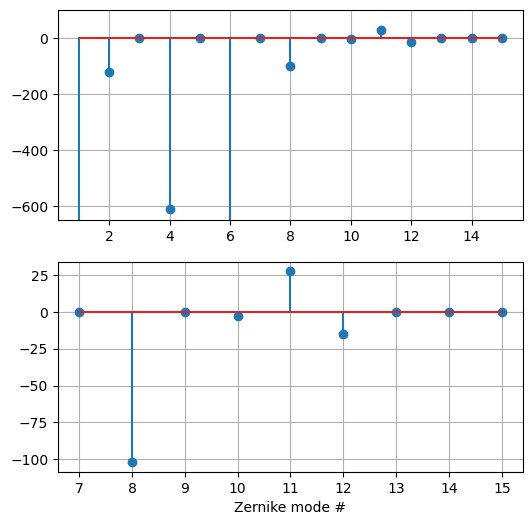

In [237]:
c = np.asarray(data[-1][1])
fig,axs=plt.subplots(nrows=2,figsize=(6,6))
ax = axs[0]
ax.stem(np.arange(1,16),c)
ax.grid()
ax.set_ylim([-650,100])
#ax.set_xlabel("Zernike mode #")
ax=axs[1]
ax.stem(np.arange(7,16),c[6:])
ax.grid()
ax.set_xlabel("Zernike mode #")


Text(0.5, 0, 'Zernike mode #')

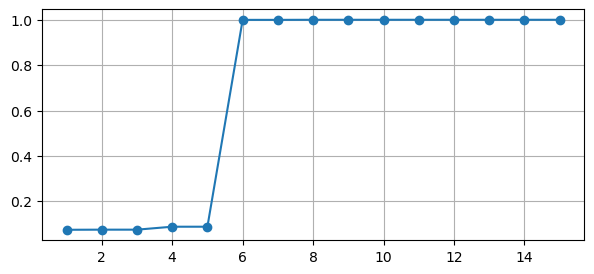

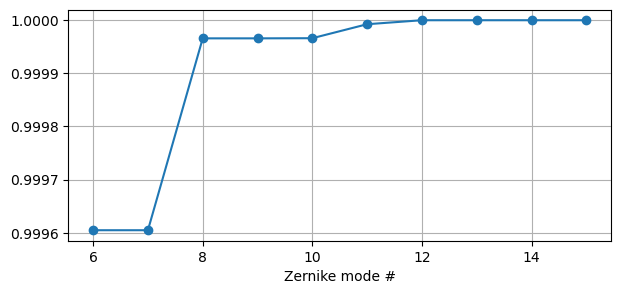

In [238]:
cc = np.cumsum(c*c)/np.sum(c*c)
fig,ax = plt.subplots(figsize=(7,3))
ax.plot(np.arange(1,16),cc,'-o')
ax.grid()
fig,ax = plt.subplots(figsize=(7,3))
ax.plot(np.arange(6,16),cc[5:],'-o')
ax.grid()
ax.set_xlabel("Zernike mode #")

In [250]:
astigmatism = np.asarray([np.hypot(x[1][4],x[1][5]) for x in data] )
#astigmatism = np.asarray([x[1][5] for x in data] )
coma = np.asarray([x[1][7] for x in data] )
spherical = np.asarray([x[1][10] for x in data] )
trefoil = np.asarray([x[1][9] for x in data] )
quadrafoil = np.asarray([x[1][11] for x in data] )

In [251]:
p_astigmatism = np.polyfit(z,astigmatism,2)
p_coma = np.polyfit(z,coma,3)
p_spherical = np.polyfit(z,spherical,2)
p_trefoil = np.polyfit(z,trefoil,3)
p_quadrafoil = np.polyfit(z,quadrafoil,4)

In [252]:
np.pi*(25.5/2)**2

510.70515574919074

In [253]:
z,p_astigmatism,p_coma,p_spherical

(array([-10. ,  -9.5,  -9. ,  -8.5,  -8. ,  -7.5,  -7. ,  -6.5,  -6. ,
         -5.5,  -5. ,  -4.5,  -4. ,  -3.5,  -3. ,  -2.5,  -2. ,  -1.5,
         -1. ,  -0.5,   0. ,   0.5,   1. ,   1.5,   2. ,   2.5,   3. ,
          3.5,   4. ,   4.5,   5. ,   5.5,   6. ,   6.5,   7. ,   7.5,
          8. ,   8.5,   9. ,   9.5,  10. ]),
 array([ 5.12787804e+01, -2.29534520e-02,  5.75920555e+00]),
 array([-1.89124034e-01,  5.97380223e-04,  8.64131676e+00, -9.37738955e-03]),
 array([ 0.27456918, -0.00084751, -0.09412743]))

In [254]:
z[20],astigmatism[20]

(0.0, 0.0006741140469534644)

In [255]:
g = 8.417/25.498
1/g

3.029345372460497

In [256]:
p_astigmatism[0]*(180*60/np.pi)**2*1e-9*2*np.sqrt(6)

2.9688692677408444

In [263]:
p_coma[2]*(180*60/np.pi)*1e-9*3*np.sqrt(8)

0.00025206935849222245

In [261]:
p_coma[0]*(180*60/np.pi)**3*1e-9*3*np.sqrt(8)

-65.19805183080794

In [264]:
p_spherical[0]*(180*60/np.pi)**2*1e-9*6*np.sqrt(5)

0.04353472474381763

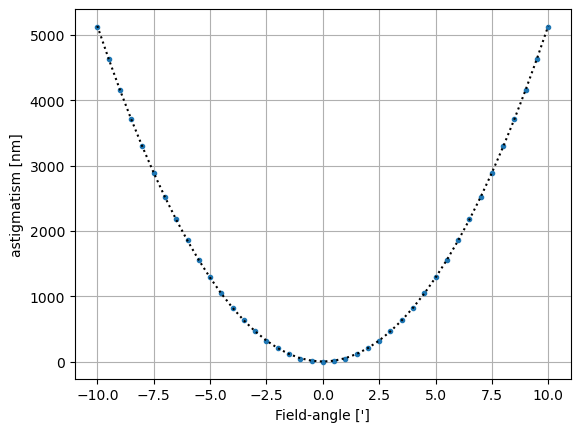

In [260]:
fig,ax = plt.subplots()
ax.plot(z,astigmatism,'.')
ax.plot(z,np.polyval(p_astigmatism,z),'k:')
ax.set_xlabel("Field-angle [']")
ax.set_ylabel("astigmatism [nm]")
ax.grid()

In [227]:
p_coma,p_spherical

(array([-0.0067454 , -0.02269945,  0.39980293, -0.16057528]),
 array([ 0.00337162, -0.01121289,  0.04180062]))

In [228]:
p_coma,p_spherical

(array([-0.0067454 , -0.02269945,  0.39980293, -0.16057528]),
 array([ 0.00337162, -0.01121289,  0.04180062]))

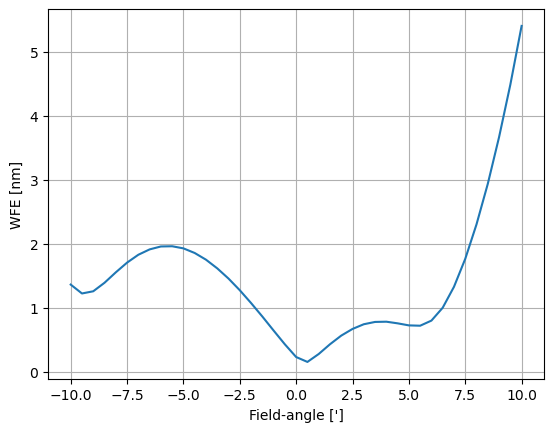

In [229]:
wfe = np.asarray([np.sqrt(np.sum(np.asarray(x[1][7:])**2)) for x in data] )
fig,ax = plt.subplots()
ax.plot(z,wfe)
#ax.set_xticks(np.arange(-10,11))
ax.set_xlabel("Field-angle [']")
ax.set_ylabel("WFE [nm]")
ax.grid()

In [230]:
np.cos(-np.pi/6),np.sqrt(3)/2

(0.8660254037844387, 0.8660254037844386)

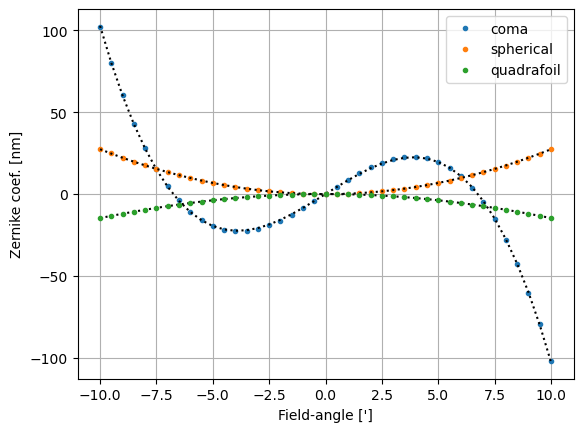

In [265]:
fig,ax = plt.subplots()
ax.plot(z,coma,'.',label="coma")
ax.plot(z,np.polyval(p_coma,z),'k:')
ax.plot(z,spherical,'.',label="spherical")
ax.plot(z,np.polyval(p_spherical,z),'k:')
ax.plot(z,np.polyval(p_quadrafoil,z),'k:')
ax.plot(z,quadrafoil,'.',label="quadrafoil")
ax.set_xlabel("Field-angle [']")
ax.set_ylabel("Zernike coef. [nm]")
ax.grid()
ax.legend()

In [77]:
p_trefoil

array([-1.44158919e-04, -1.17788268e-05,  1.77976646e-05,  1.14809420e-04])

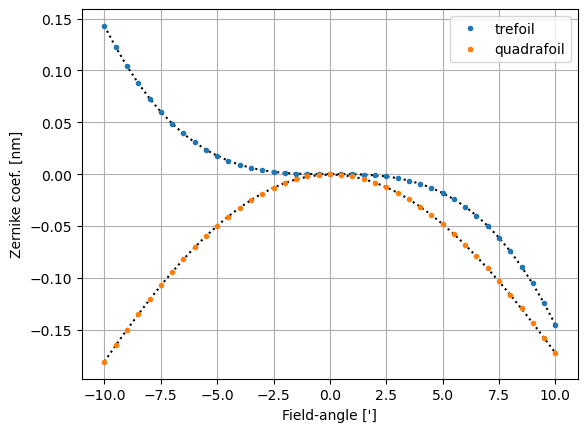

In [78]:
fig,ax = plt.subplots()
#ax.plot(z,coma,'.',label="coma")
#ax.plot(z,np.polyval(p_coma,z),'k:')
#ax.plot(z,spherical,'.',label="spherical")
ax.plot(z,np.polyval(p_trefoil,z),'k:')
ax.plot(z,trefoil,'.',label="trefoil")p_coma_s3[2]*(180*60/np.pi)*1e-9*3*np.sqrt(8)/g**3
ax.plot(z,np.polyval(p_quadrafoil,z),'k:')
ax.plot(z,quadrafoil,'.',label="quadrafoil")
ax.set_xlabel("Field-angle [']")
ax.set_ylabel("Zernike coef. [nm]")
ax.grid()
ax.legend()

In [202]:
data = np.load("field-aberrations_s1.pkl",allow_pickle=True)
coma = np.asarray([x[1][7] for x in data] )
p_coma_s1 = np.polyfit(z,coma,3)
data = np.load("field-aberrations_s3.pkl",allow_pickle=True)
coma = np.asarray([x[1][7] for x in data] )
p_coma_s3 = np.polyfit(z,coma,3)
p_coma_s1,p_coma_s3

(array([-6.82118448e-03, -2.50002443e-10,  3.27614385e-01, -3.20265706e-08]),
 array([-0.0067454 , -0.02269945,  0.39980293, -0.16057528]))

In [209]:
p_coma_s1[2]*(180*60/np.pi)*1e-9*3*np.sqrt(8)/g**3

0.0002656742495781775

In [212]:
p_coma_s3[2]*(180*60/np.pi)*1e-9*3*np.sqrt(8)/g**3

0.000324214530690737

In [213]:
s = 2*8.71/8.365
s

2.082486551105798

In [215]:
p_coma_s3[1]*(180*60/np.pi)**2*1e-9*0.25*np.sqrt(8)/g**4/(s*np.cos(-np.pi/6))

-0.008857893312315237

In [232]:
data = np.load("field-aberrations_s1.pkl",allow_pickle=True)
coma = np.asarray([x[1][6] for x in data] )
p_coma_s1 = np.polyfit(z,coma,3)
data = np.load("field-aberrations_s3.pkl",allow_pickle=True)
coma = np.asarray([x[1][6] for x in data] )
p_coma_s3 = np.polyfit(z,coma,3)
p_coma_s1,p_coma_s3

(array([ 2.02860003e-10, -5.99335315e-02, -1.29118740e-08, -1.92523938e-01]),
 array([-0.00020286,  0.03002175, -0.03365303,  0.08710252]))

In [233]:
p_coma_s3[2]*(180*60/np.pi)*1e-9*3*np.sqrt(8)/g**3

-2.7290451108538732e-05

In [234]:
p_coma_s3[1]*(180*60/np.pi)**2*1e-9*0.25*np.sqrt(8)/g**4/(s*np.sin(-np.pi/6))

-0.02029138856394243